In [1]:

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import random
import numpy as np
from collections import deque

In [2]:
env = gym.make("CartPole-v1")
# Hyperparameters
learning_rate = 0.001
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
batch_size = 64
target_update_freq = 1000
memory_size = 10000
episodes = 1000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [99]:
class DQN(nn.Module):

    def __init__(self,input_dim, output_dim):
        super(DQN,self).__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, output_dim)


    def forward(self,x):

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)
        
        

In [115]:
#initialize Q
input_dim = env.observation_space.shape[0]

output_dim = env.action_space.n

policy_net = DQN(input_dim,output_dim).to(device) 
target_net = DQN(input_dim,output_dim).to(device) 

target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(),lr=learning_rate)

memory  = deque(maxlen=memory_size)

In [116]:
def select_action(state, epsilon):

    if random.random() < epsilon:

        return env.action_space.sample()

    else:

        state = torch.FloatTensor(state).unsqueeze(0).to(device) 
        Q_values = policy_net(state)
        return torch.argmax(Q_values).item()

In [117]:
# Function to optimize the model using experience replay
def optimize_model():
    if len(memory) < batch_size:
        return

    batch = random.sample(memory,batch_size)
    state_batch, action_batch, reward_batch, next_state_batch, done_batch = zip(*batch)


    state_batch = torch.FloatTensor(state_batch).to(device) 
    action_batch = torch.LongTensor(action_batch).unsqueeze(1).to(device) 
    reward_batch = torch.FloatTensor(reward_batch).to(device) 
    next_state_batch = torch.FloatTensor(next_state_batch).to(device) 
    done_batch = torch.FloatTensor(done_batch).to(device) 

    # Q values for current state

    q_values = policy_net(state_batch).gather(1,action_batch).squeeze()

    
    # Compute target Q-values using the target network
    with torch.no_grad():
        max_next_q_values = target_net(next_state_batch).max(1)[0]
        target_q_values = reward_batch + gamma * max_next_q_values * ( 1 - done_batch)

    loss = nn.MSELoss()(q_values, target_q_values)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    

    

In [118]:

rewards_per_episode = []
steps_done = 0

for episode in range(40):
    state,_ = env.reset()
    episode_reward = 0
    done = False


    while not done:

        action = select_action(state, epsilon)

        next_state, reward, done, _,_ = env.step(action)

        memory.append((state, action, reward, next_state, done))

        state = next_state
        episode_reward += reward
        
        # Optimize model
        optimize_model()

        # update target

        if steps_done % target_update_freq ==0:
            target_net.load_state_dict(policy_net.state_dict())

        steps_done+=1

        epsilon = max(epsilon_min, epsilon_decay * epsilon)

        rewards_per_episode.append(episode_reward)
        

    

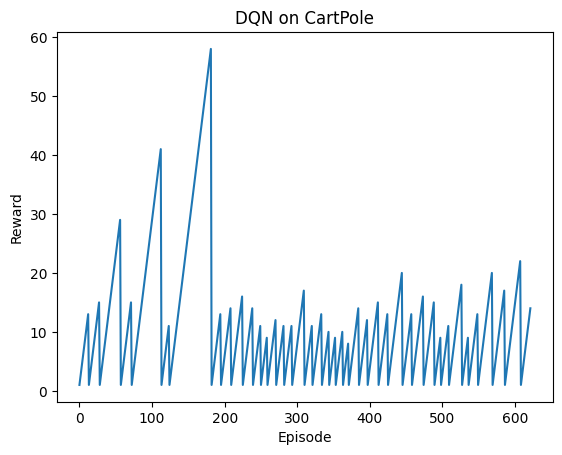

In [119]:
import matplotlib.pyplot as plt
plt.plot(rewards_per_episode)
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN on CartPole')
plt.show()